# Matematičke osnove AI: Preporuči mi film

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boba1987/vector-spaces/blob/master/ai_movie_recommender.ipynb)

Ovaj projekat implementira osnovu AI sistema za preporuku sličnih filmova oslanjajući se na sledeće matematičke pojmove:

- **vektori i dimenzije** - film kao tačka u prostoru osobina;
- **Euklidsko rastojanje / metrika** - koliko su dva filma "daleko";
- **skalarni proizvod, norma i Cauchy-Schwarz** - osnova za **kosinusnu sličnost**;
- **normalizacija** - pošteno poređenje ukusa;
- **otvorena lopta / prag sličnosti** - svi filmovi koji su dovoljno blizu;
- **rešavanje `Ax=b`** - računanje koliko korisnik preferira svaki žanr ili osobinu filma.

Koristimo ideje iz literature:

- **Vektori** - https://rksmvv.ac.in/wp-content/uploads/2021/04/Gilbert_Strang_Linear_Algebra_and_Its_Applicatio_230928_225121.pdf, Chapter 2 (Vector Spaces): stvari opisujemo brojevima i tretiramo ih kao tačke u prostoru.
- **Sličnost / rastojanje** - https://www.math.ucdavis.edu/~hunter/m125a/intro_analysis_ch7.pdf (Metric Spaces): kako izmeriti koliko su dve tačke blizu.

Svaki korak ima: **šta radimo**, **zašto** (analogija iz života), **formula** i **veza sa teorijom**.

> Glavna ideja ćelog projekta je: **AI preporuka = pretvori stvari u vektore, pa izmeri koje su najbliže / najsličnije.**

## Priprema (pokreni jednom)

Instaliramo tri standardne biblioteke i napravimo dva mala pomoćna "alata" za lepši ispis.

In [1]:
!pip -q install numpy pandas matplotlib

zsh:1: command not found: pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({'figure.figsize': (8, 6), 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})


def show_step(broj, naziv):
    # Lep naslov koraka.
    print('=' * 64)
    print(f'  KORAK {broj}: {naziv}')
    print('=' * 64)


def say(naslov, tekst):
    # Kratko objašnjenje u izlazu ćelije, da tekst i kod budu na istom mestu.
    print(f'\n>> {naslov}')
    for linija in tekst.strip().split('\n'):
        print(f'   {linija.strip()}')


print('Sve spremno!')

Sve spremno. Pokreni ćelije redom, od vrha ka dnu.


## Podaci: opišimo filmove brojevima

**Problem:** računar ne razume rečenicu "ovo je romantična komedija". Ali razume **brojeve**.

**Rešenje:** svaki film ocenimo po nekoliko osobina, ocenom od 0 do 10:
- `akcija` - koliko ima akcije
- `romansa` - koliko je romantično
- `komedija` - koliko je smešno
- `tempo` - koliko je dinamično
- `ozbiljnost` - koliko je ozbiljna tema

Tako svaki film postaje red brojeva. To je sve što AI-u treba za početak.

In [3]:
# Osobine kojima opisujemo svaki film (ocene 0-10).
osobine = ['akcija', 'romansa', 'komedija', 'tempo', 'ozbiljnost']

# Mala "baza" filmova. Brojevi su izmišljeni radi primera.
filmovi = {
    'Velika Pljačka':        [9, 1, 2, 9, 6],   # akcioni triler
    'Jurnjava Gradom':       [8, 2, 3, 9, 5],   # akcioni
    'Heroj Bez Straha':      [9, 2, 1, 8, 7],   # akcioni
    'Ljubav u Parizu':       [1, 9, 4, 3, 5],   # romansa
    'Pismo za Tebe':         [1, 9, 3, 2, 6],   # romansa
    'Leto Kada Smo Se Sreli':[2, 8, 5, 4, 4],   # romansa/dramedija
    'Ludi Provod':           [3, 2, 9, 8, 1],   # komedija
    'Kancelarijske Muke':    [1, 3, 9, 5, 2],   # komedija
    'Tihi Okean':            [2, 4, 1, 2, 9],   # ozbiljna drama
    'Poslednji Dan':         [4, 3, 1, 4, 9],   # ozbiljna drama
}

df = pd.DataFrame.from_dict(filmovi, orient='index', columns=osobine)
df.index.name = 'film'

say('Šta smo uradili',
    'Svaki film smo opisali sa 5 brojeva (po jedna ocena za svaku osobinu).\n'
    'Sada je svaki film jedan red u tabeli ispod.')
display(df)
print(f'\nUkupno filmova: {len(df)} | Osobina po filmu: {len(osobine)}')


>> Šta smo uradili
   Svaki film smo opisali sa 5 brojeva (po jedna ocena za svaku osobinu).
   Sada je svaki film jedan red u tabeli ispod.


,akcija,romansa,komedija,tempo,ozbiljnost
film,,,,,
Velika Pljačka,9,1,2,9,6
Jurnjava Gradom,8,2,3,9,5
Heroj Bez Straha,9,2,1,8,7
Ljubav u Parizu,1,9,4,3,5
Pismo za Tebe,1,9,3,2,6
Leto Kada Smo Se Sreli,2,8,5,4,4
Ludi Provod,3,2,9,8,1
Kancelarijske Muke,1,3,9,5,2
Tihi Okean,2,4,1,2,9



Ukupno filmova: 10 | Osobina po filmu: 5


## Korak 1: film je vektor (tačka u prostoru)

**Šta radimo:** red brojeva za jedan film zovemo **vektor**. Vektor možemo da zamislimo kao **tačku** (ili strelicu od koordinatnog početka) u prostoru.

**Zašto:** ako je film tačka, onda "slični filmovi" = "tačke koje su blizu jedna drugoj". Cela preporuka se svodi na geometriju! Analogija: kao gradovi na mapi - samo što naša "mapa" ima 5 pravaca (5 osobina) umesto 2.

**Matematika iza toga:** film je `x = (x1, x2, x3, x4, x5)`, gde je svaki `xi` ocena jedne osobine. Skup svih takvih vektora je **vektorski prostor**.

**Veza sa teorijom:** Strang, poglavlje 2 - 2.1 (vektorski prostor: smemo da sabiramo i skaliramo vektore) i 2.3 (svaka osobina je jedna **dimenzija**; naš prostor ima 5 dimenzija).

  KORAK 1: Film je vektor (tačka u prostoru)

>> Primer jednog filma kao vektor
   "Ljubav u Parizu" -> [np.int64(1), np.int64(9), np.int64(4), np.int64(3), np.int64(5)]
   To znači: akcija=1, romansa=9, komedija=4, tempo=3, ozbiljnost=5.


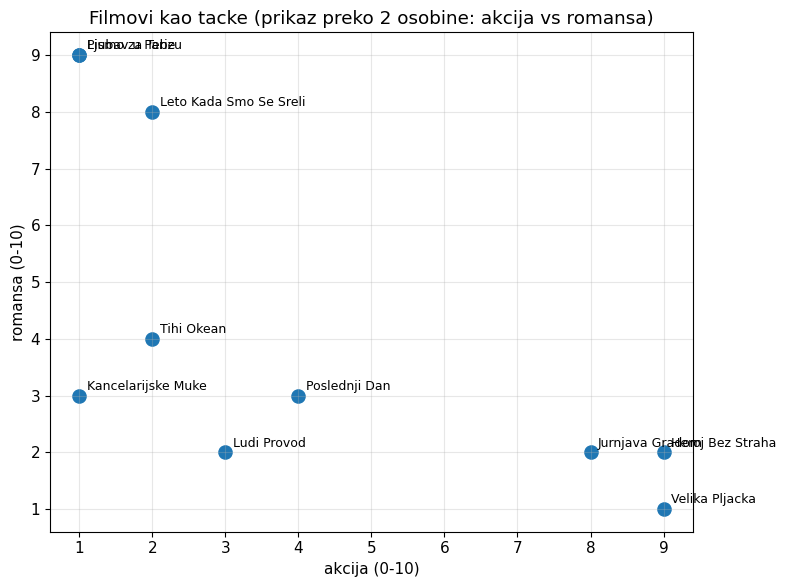


>> Šta vidimo
   Akcioni filmovi se grupišu desno (visoka akcija), romantični gore-levo (visoka romansa).
   Već golim okom vidimo da "blizu = slično". To je suština preporuke.


In [ ]:
show_step(1, 'Film je vektor (tačka u prostoru)')

# Matrica X: svaki red je jedan film kao vektor brojeva.
X = df.values.astype(float)
print(f'\nVektorski prostor: {X}')
imena = df.index.tolist()

# Pogledajmo jedan film kao vektor.
primer = 'Ljubav u Parizu'
vek = df.loc[primer].values
say('Primer jednog filma kao vektor',
    f'"{primer}" -> {list(vek)}\n'
    f'To znači: akcija={vek[0]}, romansa={vek[1]}, komedija={vek[2]}, tempo={vek[3]}, ozbiljnost={vek[4]}.')

# Crtamo filmove koristeći samo 2 osobine (da bismo mogli da ih vidimo na ravnoj slici).
osa_x, osa_y = 'akcija', 'romansa'
fig, ax = plt.subplots()
ax.scatter(df[osa_x], df[osa_y], s=90)
for ime in imena:
    ax.annotate(ime, (df.loc[ime, osa_x] + 0.1, df.loc[ime, osa_y] + 0.1), fontsize=9)
ax.set_xlabel(f'{osa_x} (0-10)'); ax.set_ylabel(f'{osa_y} (0-10)')
ax.set_title('Filmovi kao tačke (prikaz preko 2 osobine: akcija vs romansa)')
plt.tight_layout(); plt.show()

say('Šta vidimo',
    'Akcioni filmovi se grupišu desno (visoka akcija), romantični gore-levo (visoka romansa).\n'
    'Već golim okom vidimo da "blizu = slično". To je suština preporuke.')

## Korak 2: koliko su dva filma "daleko"?

**Šta radimo:** računamo **rastojanje** između dva filma (dve tačke). Manje rastojanje = sličniji filmovi.

**Zašto:** to je najprirodniji način da kažemo "blizu = slično". Analogija: vazdušna linija između dva grada - što je kraća, gradovi su bliži.

**Matematika iza toga (Euklidsko rastojanje):**

\[ d(x, y) = \sqrt{(x_1-y_1)^2 + (x_2-y_2)^2 + \... + (x_5-y_5)^2} \]

Rečima: za svaku osobinu nađemo razliku, kvadriramo je (da nestane minus i da veće razlike više "kažnjavaju"), sve saberemo i izvučemo koren. Isto kao Pitagorina teorema, samo u 5 dimenzija.

**Veza sa teorijom:** Analysis, poglavlje 7 - definicija 7.1 (šta uopšte mora da važi da bi nešto bilo "rastojanje": nije negativno, simetrično je, i poštuje nejednakost trougla) i vežba 7.4/7.5 (Euklidska formula).

In [5]:
show_step(2, 'Rastojanje između dva filma (Euklidsko)')

def rastojanje(x, y):
    # d(x,y) = sqrt( zbir kvadrata razlika po svakoj osobini )
    return np.sqrt(np.sum((x - y) ** 2))

# Uporedimo dva slična i dva različita filma.
a, b, c = 'Velika Pljačka', 'Jurnjava Gradom', 'Ljubav u Parizu'
d_slični = rastojanje(df.loc[a].values, df.loc[b].values)
d_različiti = rastojanje(df.loc[a].values, df.loc[c].values)

say('Dva akciona filma (treba da budu blizu)',
    f'd("{a}", "{b}") = {d_slični:.2f}')
say('Akcioni vs romantični (treba da budu daleko)',
    f'd("{a}", "{c}") = {d_različiti:.2f}')
print(f'\nManji broj = sličniji. Vidimo: {d_slični:.2f} < {d_različiti:.2f}  -> formula se slaze sa intuicijom.')

# Tablica rastojanja od jednog filma do svih ostalih.
početni = 'Velika Pljačka'
rastojanja = {ime: rastojanje(df.loc[početni].values, df.loc[ime].values) for ime in imena}
tabela_d = pd.Series(rastojanja).sort_values().rename('rastojanje_od_' + početni.replace(' ', '_'))
say('Rastojanje od "' + početni + '" do svih (sortirano, manje = sličnije)', '')
display(tabela_d.to_frame().round(2))

  KORAK 2: Rastojanje između dva filma (Euklidsko)

>> Dva akciona filma (treba da budu blizu)
   d("Velika Pljačka", "Jurnjava Gradom") = 2.00

>> Akcioni vs romantični (treba da budu daleko)
   d("Velika Pljačka", "Ljubav u Parizu") = 13.00

Manji broj = sličniji. Vidimo: 2.00 < 13.00  -> formula se slaze sa intuicijom.

>> Rastojanje od "Velika Pljačka" do svih (sortirano, manje = sličnije)
   


,rastojanje_od_Velika_Pljačka
Velika Pljačka,0.00
Jurnjava Gradom,2.00
Heroj Bez Straha,2.00
Poslednji Dan,8.00
Ludi Provod,10.58
Tihi Okean,10.82
Leto Kada Smo Se Sreli,11.66
Kancelarijske Muke,12.21
Ljubav u Parizu,13.00
Pismo za Tebe,13.34


## Korak 3: kada je važniji "ukus" nego "jačina ocene"

**Problem:** zamislimo dva gledalaca. Jedan svemu daje visoke ocene, drugi svemu niske - ali im je **ukus isti** (oboje vole akciju, ne vole romansu). Rastojanje bi ih proglasilo različitima samo zato što su brojevi po veličini različiti.

**Rešenje:** gledamo **ugao** između dva vektora, a ne njihovu dužinu. Ako "gledaju u istom pravcu", ukus je isti.

**Matematika iza toga (kosinusna sličnost):**

\[ \cos(x, y) = \frac{\langle x, y\rangle}{\lVert x\rVert \, \lVert y\rVert} \]

- `<x,y>` (skalarni proizvod) = saberemo `x1*y1 + x2*y2 + ...`; meri "koliko se poklapaju".
- `||x||` = dužina vektora (delimo njime da bi dužina prestala da bude bitna).
- Rezultat je broj od **-1 do 1**: blizu 1 = isti ukus, oko 0 = nepovezano.

**Zašto baš od -1 do 1?** Zbog **Cauchy-Schwarz** nejednakosti: brojilac `<x,y>` nikada ne može biti veći od imenioca `||x|| ||y||`. Zato razlomak ostaje između -1 i 1.

> **Napomena:** sam pojam "kosinusna sličnost" se ne pominje u literaturi. Ali ga ovde **sklapamo od pojmova koji jesu u vektorskim prostorima**: skalarni proizvod i dužina (vežba 7.15) + granica [-1, 1] preko Cauchy-Schwarz (teorema 7.54).

**Veza sa teorijom:** Analysis, poglavlje 7 - teorema 7.54 (Cauchy-Schwarz) i vežba 7.15 (skalarni proizvod i dužina). Kosinusna sličnost = skalarni proizvod podeljen dužinama; sam naziv nije iz knjige, ali su svi sastojci.

In [6]:
show_step(3, 'Kosinusna sličnost (gledamo ugao, ne veličinu)')

def cosine(x, y):
    return float(np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y)))


def prikazi_kosinus(x, y, ime_x='x', ime_y='y'):
    """Ispis korak-po-korak: skalarni proizvod, norme, kosinusna sličnost."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    oznake = list(df.columns)

    say(f'Računanje kosinusne sličnosti: {ime_x} vs {ime_y}',
        '\n'.join(f'{o}: {ime_x}={xi:.0f}, {ime_y}={yi:.0f}'
                  for o, xi, yi in zip(oznake, x, y)))

    proizvodi = x * y
    skalar = float(np.dot(x, y))
    sabirci = ' + '.join(f'{p:.0f}' for p in proizvodi)
    print(f'   1) Skalarni proizvod <{ime_x}, {ime_y}> = {sabirci} = {skalar:.2f}')

    kvadrati_x = x ** 2
    kvadrati_y = y ** 2
    norm_x = float(np.linalg.norm(x))
    norm_y = float(np.linalg.norm(y))
    print(f'   2) Dužina ||{ime_x}|| = sqrt({" + ".join(f"{k:.0f}" for k in kvadrati_x)}) = {norm_x:.2f}')
    print(f'   3) Dužina ||{ime_y}|| = sqrt({" + ".join(f"{k:.0f}" for k in kvadrati_y)}) = {norm_y:.2f}')

    kos = skalar / (norm_x * norm_y)
    print(f'   4) cos = {skalar:.2f} / ({norm_x:.2f} × {norm_y:.2f}) = {kos:.4f}')
    return kos


# Pokažimo problem sa "jačinom ocena":
# isti ukus, ali jedan gledalac sve duplira (veće ocene).
ukus_A = np.array([8, 2, 1, 7, 3], dtype=float)
ukus_B = ukus_A * 2          # isti pravac, dvostruke ocene
ukus_C = np.array([1, 9, 8, 2, 6], dtype=float)  # drugačiji ukus

say('Isti ukus, različita "jačina" ocena',
    f'A = {list(ukus_A.astype(int))}\nB = {list(ukus_B.astype(int))}  (= A puta 2)')
print(f'   Rastojanje A-B = {rastojanje(ukus_A, ukus_B):.2f}  (veliko! deluje različito - a nije)')
kos_ab = prikazi_kosinus(ukus_A, ukus_B, 'A', 'B')
print(f'   -> kosinusna sličnost A-B = {kos_ab:.3f}  (≈1.0 -> prepoznaje da je ukus isti)')

say('Drugačiji ukus',
    f'C = {list(ukus_C.astype(int))}')
kos_ac = prikazi_kosinus(ukus_A, ukus_C, 'A', 'C')
print(f'   -> kosinusna sličnost A-C = {kos_ac:.3f}  (nisko -> različit ukus)')

# Provera granica iz Cauchy-Schwarz: kosinusna sličnost je uvek u [-1, 1].
sve_kosine = [cosine(df.loc[i].values, df.loc[j].values) for i in imena for j in imena]
print(f'\n[provera] Najmanja kosinusna sličnost={min(sve_kosine):.3f}, najveća={max(sve_kosine):.3f} '
      f'-> zaista ostaje u [-1, 1] (Cauchy-Schwarz, teorema 7.54).')

  KORAK 3: Kosinusna sličnost (gledamo ugao, ne veličinu)

>> Isti ukus, različita "jačina" ocena
   A = [np.int64(8), np.int64(2), np.int64(1), np.int64(7), np.int64(3)]
   B = [np.int64(16), np.int64(4), np.int64(2), np.int64(14), np.int64(6)]  (= A puta 2)
   Rastojanje A-B = 11.27  (veliko! deluje različito - a nije)
   kosinusna sličnost A-B = 1.000  (≈1.0 -> prepoznaje da je ukus isti)

>> Drugačiji ukus
   C = [np.int64(1), np.int64(9), np.int64(8), np.int64(2), np.int64(6)]
   kosinusna sličnost A-C = 0.429  (nisko -> različit ukus)

[provera] Najmanja kosinusna sličnost=0.370, najveća=1.000 -> zaista ostaje u [-1, 1] (Cauchy-Schwarz, teorema 7.54).


## Korak 4: zašto "normalizujemo"

**Šta radimo:** svaki vektor normalizujemo tako što ga svedemo na **dužinu 1** (zadrži pravac).

**Zašto:** da poređenje bude pošteno - da nas ne zavara to što je neko davao veće brojeve. Analogija: poredimo **oblik** stvari, a ne koliko je velika.

**Matematika iza toga:**
- **Norma** (dužina) vektora: `||x|| = sqrt(x1^2 + x2^2 + ...)`.
- Normalizovan vektor: `x / ||x||` - sada mu je dužina tačno 1.
- Zgodno: kosinusna sličnost je upravo obican skalarni proizvod **normalizovanih** vektora.

**Veza sa teorijom:** Analysis, poglavlje 7 - definicija 7.11 (norma = "dužina", sa pravilima: nije negativna, množenje brojem množi dužinu, važi nejednakost trougla).

In [7]:
show_step(4, 'Normalizačija (poredimo oblik, ne veličinu)')

def normalizuj(x):
    dužina = np.linalg.norm(x)
    return x / dužina if dužina > 0 else x

v = df.loc['Ljubav u Parizu'].values
v_norm = normalizuj(v)

say('Pre i posle normalizacije',
    f'original = {list(v)}, dužina = {np.linalg.norm(v):.2f}\n'
    f'normalizovan = {np.round(v_norm, 2).tolist()}, dužina = {np.linalg.norm(v_norm):.2f}')

# Dokaz da je kosinusna sličnost = skalarni proizvod normalizovanih vektora.
x = df.loc['Velika Pljačka'].values
y = df.loc['Jurnjava Gradom'].values
levo = cosine(x, y)
desno = float(np.dot(normalizuj(x), normalizuj(y)))
print(f'\n[provera] kosinusna sličnost(x,y) = {levo:.4f}')
print(f'[provera] <x_norm, y_norm> = {desno:.4f}   -> isto! (normalizačija + skalarni proizvod = kosinusna sličnost)')

say('Zaključak',
    'Posle normalizacije svi vektori imaju istu dužinu (1), pa poredimo samo PRAVAC = ukus.\n'
    'To je tačno ono što želimo od preporuke.')

  KORAK 4: Normalizačija (poredimo oblik, ne veličinu)

>> Pre i posle normalizacije
   original = [np.int64(1), np.int64(9), np.int64(4), np.int64(3), np.int64(5)], dužina = 11.49
   normalizovan = [0.09, 0.78, 0.35, 0.26, 0.44], dužina = 1.00

[provera] kosinusna sličnost(x,y) = 0.9910
[provera] <x_norm, y_norm> = 0.9910   -> isto! (normalizačija + skalarni proizvod = kosinusna sličnost)

>> Zaključak
   Posle normalizacije svi vektori imaju istu dužinu (1), pa poredimo samo PRAVAC = ukus.
   To je tačno ono što želimo od preporuke.


## Korak 5: napravi preporuku (sve se spaja)

**Šta radimo:** za film koji voliš, izračunamo sličnost prema svim ostalim filmovima, poređamo ih od najsličnijeg ka najmanje sličnom, i vratimo prvih nekoliko.

**Zašto:** Sve što smo radili u koracima 1-4 sada se koristi ovde.

**Matematika iza toga:** koristimo **kosinusnu sličnost** (Korak 3 + 4). Veća sličnost = bolja preporuka.

**Bonus (prag sličnosti):** umesto "daj mi tačno 3", možemo reći "daj mi sve filmove čija je sličnost preko npr. 0.9". To je ideja **lopte** oko filma (Analysis, poglavlje 7, definicija 7.18): skup svih tačaka koje su dovoljno blizu.

In [8]:
show_step(5, 'Preporuka filmova')

def preporuči(naziv_filma, n=3):
    if naziv_filma not in df.index:
        print(f'Nemam film "{naziv_filma}" u bazi.'); return None
    osnova = df.loc[naziv_filma].values
    sličnosti = {ime: cosine(osnova, df.loc[ime].values) for ime in imena if ime != naziv_filma}
    rang = pd.Series(sličnosti).sort_values(ascending=False)
    return rang.head(n)

def preporuči_u_lopti(naziv_filma, prag=0.9):
    # definicija 7.18: svi filmovi čija je sličnost >= prag (tj. dovoljno "blizu").
    osnova = df.loc[naziv_filma].values
    sličnosti = {ime: cosine(osnova, df.loc[ime].values) for ime in imena if ime != naziv_filma}
    rang = pd.Series(sličnosti).sort_values(ascending=False)
    return rang[rang >= prag]

# Primer 1: akcioni film.
izbor = 'Velika Pljačka'
say(f'Pošto ti se sviđeo: "{izbor}"', 'Top 3 preporuke (po kosinusnoj sličnosti):')
display(preporuči(izbor, n=3).rename('sličnost').to_frame().round(3))

# Primer 2: romantični film.
izbor2 = 'Ljubav u Parizu'
say(f'Pošto ti se sviđeo: "{izbor2}"', 'Top 3 preporuke:')
display(preporuči(izbor2, n=3).rename('sličnost').to_frame().round(3))

# Bonus: prag sličnosti (lopta oko filma).
prag = 0.95
u_lopti = preporuči_u_lopti(izbor, prag=prag)
say(f'Svi filmovi sličniji od {prag} filmu "{izbor}" (definicija 7.18 - lopta)',
    f'Pronađeno: {len(u_lopti)} film(ova).')
display(u_lopti.rename('sličnost').to_frame().round(3))

  KORAK 5: Preporuka filmova

>> Pošto ti se sviđeo: "Velika Pljačka"
   Top 3 preporuke (po kosinusnoj sličnosti):


,sličnost
Jurnjava Gradom,0.991
Heroj Bez Straha,0.990
Poslednji Dan,0.829



>> Pošto ti se sviđeo: "Ljubav u Parizu"
   Top 3 preporuke:


,sličnost
Pismo za Tebe,0.989
Leto Kada Smo Se Sreli,0.981
Tihi Okean,0.786



>> Svi filmovi sličniji od 0.95 filmu "Velika Pljačka" (definicija 7.18 - lopta)
   Pronađeno: 2 film(ova).


,sličnost
Jurnjava Gradom,0.991
Heroj Bez Straha,0.990


## Korak 6: napravi željeni ukus kao mešavinu filmova ("recept")

**Šta radimo:** do sada smo pitali "nađi sličan film". Sada pitamo obrnuto: *koliko kog filma da pomešam da dobijem tačno željeni ukus?*

**Zašto:** kao **recept** ili **mešanje boja** - "nijansa" je ciljani ukus.

**Matematika iza toga:** trazimo količine `x` tako da važi

\[ A\,x = b \]

- kolone matrice `A` = vektori filmova-sastojaka,
- `x` = koliko kog filma ubacujemo (to je "recept" koji trazimo),
- `b` = željeni ukus (5 brojeva).

Rešavanje ove jednačine po `x` je baš tema ove funkcionalnosti. Ako željeni ukus jeste moguća mešavina, dobijamo tačan recept; ako nije, isti postupak vraća **najbližu** moguću mešavinu.

**Kako se ovo spaja sa preporukom:** kad jednom imamo željeni ukus `b`, iskoristimo ga kao **upit** - preporučimo pravi film iz baze koji je najbliži tom ukusu (kosinusna sličnost iz Koraka 3). Tako `Ax=b` postaje stvarni ulaz u krajnji rezultat: korisnik opiše željeni ukus, a sistem vrati konkretan film.

**Veza sa teorijom:** Strang, poglavlje 2 - **2.2 (Solving `Ax=0` and `Ax=b`)**.

In [9]:
show_step(6, 'Recept: željeni ukus kao mešavina filmova (Ax = b)')

# Biramo nekoliko filmova kao "sastojke". Njihovi vektori su KOLONE matrice A.
sastojci = ['Velika Pljačka', 'Ljubav u Parizu', 'Ludi Provod']
A = np.array([df.loc[s].values for s in sastojci], dtype=float).T  # oblik: 5 osobina x 3 filma

# Zamislimo željeni ukus kao stvarnu mešavinu (pa znamo da rešenje postoji):
# 50% prvog + 30% drugog + 20% treceg filma.
prave_količine = np.array([0.5, 0.3, 0.2])
b = A @ prave_količine  # ciljani profil ukusa (5 brojeva, po jedan za svaku osobinu)

say('Pitanje',
    f'Koliko kog filma da pomešam da dobijem baš ovaj ukus?\n'
    f'Sastojci (kolone A): {sastojci}\n'
    f'Cilj b (po osobinama {osobine}): {np.round(b, 2).tolist()}')

# Rešavamo A x = b  ->  x je "recept" (količina svakog filma).
x, *_ = np.linalg.lstsq(A, b, rcond=None)
rekonstrukčija = A @ x
greška = np.linalg.norm(rekonstrukčija - b)

say('Rešenje - recept (x)',
    '\n'.join(f'{s}: {kol:.2f}' for s, kol in zip(sastojci, x)))
print(f'\n[provera] A @ x = {np.round(rekonstrukcija, 2).tolist()}')
print(f'[provera] cilj b  = {np.round(b, 2).tolist()}')
print(f'[provera] greška ||A x - b|| = {greška:.6f}  (≈0 -> recept tačno pogađa željeni ukus)')

say('Šta ovo znači',
    'Rešili smo jednačinu A x = b: našli smo količine (recept) kojima mešavina filmova\n'
    'daje baš željeni ukus. To je upravo "Solving Ax=b" iz Strang 2.2 - samo u temi filmova.')


# --- Spajanje sa preporukom: željeni ukus b koristimo kao upit ---
def preporuči_za_ukus(ukus, n=3):
    # Vrati prave filmove iz baze najbliže datom ukusu (kosinusna sličnost iz Koraka 3).
    sličnosti = {ime: cosine(ukus, df.loc[ime].values) for ime in imena}
    return pd.Series(sličnosti).sort_values(ascending=False).head(n)

preporuke_za_b = preporuči_za_ukus(b, n=3)
najblizi_filmu_b = preporuke_za_b.index[0]

say('Korak 6 ulazi u krajnji rezultat',
    'Željeni ukus b sad koristimo kao upit i trazimo prave filmove iz baze najbliže tom ukusu:')
display(preporuke_za_b.rename('sličnost').to_frame().round(3))
print(f'-> Za željeni ukus preporučujemo: "{najblizi_filmu_b}"')

  KORAK 6: Recept: željeni ukus kao mešavina filmova (Ax = b)

>> Pitanje
   Koliko kog filma da pomešam da dobijem baš ovaj ukus?
   Sastojci (kolone A): ['Velika Pljačka', 'Ljubav u Parizu', 'Ludi Provod']
   Cilj b (po osobinama ['akcija', 'romansa', 'komedija', 'tempo', 'ozbiljnost']): [5.4, 3.6, 4.0, 7.0, 4.7]

>> Rešenje - recept (x)
   Velika Pljačka: 0.50
   Ljubav u Parizu: 0.30
   Ludi Provod: 0.20

[provera] A @ x = [5.4, 3.6, 4.0, 7.0, 4.7]
[provera] cilj b  = [5.4, 3.6, 4.0, 7.0, 4.7]
[provera] greška ||A x - b|| = 0.000000  (≈0 -> recept tačno pogađa željeni ukus)

>> Šta ovo znači
   Rešili smo jednačinu A x = b: našli smo količine (recept) kojima mešavina filmova
   daje baš željeni ukus. To je upravo "Solving Ax=b" iz Strang 2.2 - samo u temi filmova.

>> Korak 6 ulazi u krajnji rezultat
   Željeni ukus b sad koristimo kao upit i trazimo prave filmove iz baze najbliže tom ukusu:


,sličnost
Jurnjava Gradom,0.968
Velika Pljačka,0.935
Heroj Bez Straha,0.927


-> Za željeni ukus preporučujemo: "Jurnjava Gradom"


## Mapa filmova: vidimo preporuke svojim ocima

**Šta radimo:** nacrtamo sve filmove kao tačke i povučemo linije od izabranog filma do njegovih preporuka.

**Zašto:** da se uverimo da preporuke zaista "imaju smisla" - da povezuju bliske tačke. Koristimo 2 osobine (akcija, romansa) za prikaz na ravnoj slici.

Crvenim **X** je označen i *željeni ukus* `b` iz Koraka 6 (recept), sa linijom ka filmu koji mu je najbliži - tako se vidi i kako rezultat Koraka 6 (`Ax=b`) ulazi u preporuku.

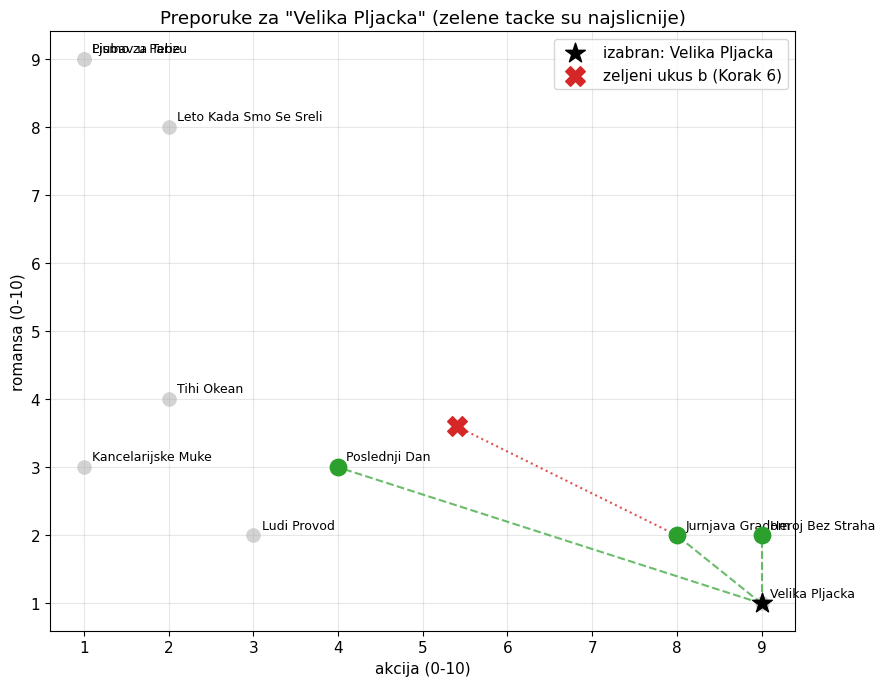


>> Šta vidimo
   Zelene linije idu ka tačkama koje su najbliže izabranom filmu (zvezdici).
   Crveni X je željeni ukus b (Korak 6); crvena linija vodi ka filmu "Jurnjava Gradom",
   koji je najbliži tom ukusu. Preporuka = "nađi najbliže tačke", tačno kao što smo i očekivali.


In [10]:
izabran = 'Velika Pljačka'
preporuke = preporuči(izabran, n=3)

osa_x, osa_y = 'akcija', 'romansa'
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df[osa_x], df[osa_y], s=90, color='lightgray')

# Izabrani film + linije ka preporukama.
px, py = df.loc[izabran, osa_x], df.loc[izabran, osa_y]
ax.scatter([px], [py], s=220, marker='*', color='black', zorder=5, label=f'izabran: {izabran}')
for ime in preporuke.index:
    qx, qy = df.loc[ime, osa_x], df.loc[ime, osa_y]
    ax.plot([px, qx], [py, qy], '--', color='tab:green', alpha=0.7)
    ax.scatter([qx], [qy], s=140, color='tab:green', zorder=4)

# Korak 6: željeni ukus b (kao tačka) + linija ka filmu koji mu je najbliži.
bx, by = b[osobine.index(osa_x)], b[osobine.index(osa_y)]
rx, ry = df.loc[najblizi_filmu_b, osa_x], df.loc[najblizi_filmu_b, osa_y]
ax.scatter([bx], [by], s=200, marker='X', color='tab:red', zorder=6, label='željeni ukus b (Korak 6)')
ax.plot([bx, rx], [by, ry], ':', color='tab:red', alpha=0.8)

for ime in imena:
    ax.annotate(ime, (df.loc[ime, osa_x] + 0.1, df.loc[ime, osa_y] + 0.1), fontsize=9)

ax.set_xlabel(f'{osa_x} (0-10)'); ax.set_ylabel(f'{osa_y} (0-10)')
ax.set_title(f'Preporuke za "{izabran}" (zelene tačke su najsličnije)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

say('Šta vidimo',
    'Zelene linije idu ka tačkama koje su najbliže izabranom filmu (zvezdici).\n'
    f'Crveni X je željeni ukus b (Korak 6); crvena linija vodi ka filmu "{najblizi_filmu_b}",\n'
    'koji je najbliži tom ukusu. Preporuka = "nađi najbliže tačke", tačno kao što smo i očekivali.')

## Rekapitulacija: gde je bila matematika i zašto

Čestitamo - napravio/la si pravi (mali) AI sistem za preporuke! Evo šta smo koristili i zašto:

| Korak | Šta smo radili | Koja matematika | Zašto nam je trebala |
|---|---|---|---|
| 1 | Film -> niz brojeva | **Vektori** (Strang 2.1, 2.3) | računar poredi brojeve, ne reči; film postaje tačka |
| 2 | "Koliko su daleko" | **Rastojanje / metrika** (poglavlje 7, definicija 7.1, vežba 7.4) | blizu = slično |
| 3 | "Isti ukus?" | **Skalarni proizvod + norma + Cauchy-Schwarz** (poglavlje 7, vežba 7.15, teorema 7.54) | gledamo pravac, ne veličinu ocena; "kosinusna sličnost" je samo naziv za taj razlomak (nije iz knjige), vrednost ostaje u [-1,1] |
| 4 | Pošteno poređenje | **Norma / normalizacija** (poglavlje 7, definicija 7.11) | da nas ne zavara ko daje veće brojeve |
| 5 | Prava preporuka | sve gore + **prag/lopta** (poglavlje 7, definicija 7.18) | poređamo po sličnosti i vratimo najbolje |
| 6 | Recept za željeni ukus | **Rešavanje `Ax=b`** (Strang 2.2) | mešamo filmove da dobijemo ciljani ukus |

### Glavna poruka

> **AI preporuka = pretvori stvari u vektore (Strang, poglavlje 2), pa izmeri koje su najsličnije (Analysis, poglavlje 7).**

Isti recept koriste i veliki sistemi (muzika, kupovina, video) - samo sa milionima stavki i stotinama osobina koje se uče iz podataka. Matematička osnova je ista.